<a href="https://colab.research.google.com/github/jiwon124/2026-1-CV/blob/main/opencv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# [HW#3] MLP 신경망 성능에 영향을 주는 요소별 실험과 분석과제
# 2022041079 서지원

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms

# 난수 시드 고정
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

------------------------------------------------------------
[실험 A]
------------------------------------------------------------


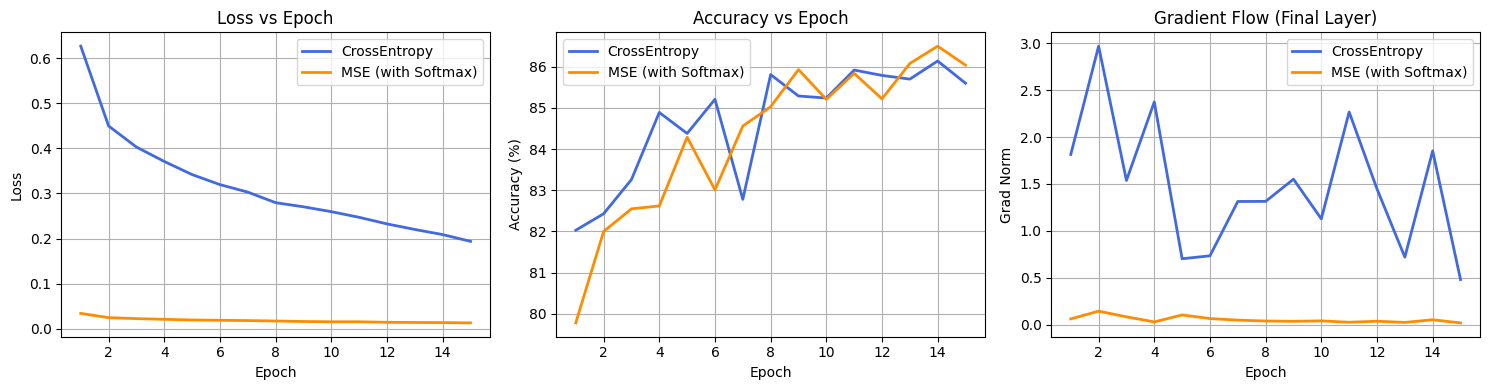

정량적 비교 데이터
  - CrossEntropy 최종 검증 정확도    : 85.60% | 최소 Loss: 0.1937
  - MSE (with Softmax) 최종 검증 정확도: 86.04% | 최소 Loss: 0.0130


In [ ]:
print("-" * 60)
print("[실험 A]")
print("-" * 60)

# Fashion-MNIST 데이터셋 로드
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set_a = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

subset_indices = torch.randperm(len(full_train_set))[:15000]
train_set_a = torch.utils.data.Subset(full_train_set, subset_indices)

train_loader_a = DataLoader(train_set_a, batch_size=64, shuffle=True)
test_loader_a = DataLoader(test_set_a, batch_size=64, shuffle=False)

# MLP 구조 정의
class MLPForExpA(nn.Module):
    def __init__(self):
        super(MLPForExpA, self).__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(784, 256), # 입력층 -> 첫 번째 은닉층 (784 -> 256)
            nn.ReLU(), # ReLU 적용
            nn.Linear(256, 128), # 첫 번째 은닉층 -> 두 번째 은닉층 (256 -> 128)
            nn.ReLU(), # ReLU 적용
            nn.Linear(128, 10) # 두 번째 은닉층 -> 출력층 (128 -> 10 클래스 개수)
        )
    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

def run_experiment_a(loss_type='CE'):
    model = MLPForExpA().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.002)
    history = {'train_loss': [], 'test_acc': [], 'grad_norm': []}

    for epoch in range(15):
        model.train()
        epoch_loss = 0.0
        for inputs, targets in train_loader_a:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            logits = model(inputs)

            if loss_type == 'CE':
                loss = nn.CrossEntropyLoss()(logits, targets)
            elif loss_type == 'MSE':
                targets_onehot = F.one_hot(targets, num_classes=10).float()
                outputs = torch.softmax(logits, dim=1)
                loss = nn.MSELoss()(outputs, targets_onehot)

            loss.backward()
            grad_norm = model.net[-1].weight.grad.norm().item()
            optimizer.step()
            epoch_loss += loss.item() * inputs.size(0)

        epoch_loss /= len(train_loader_a.dataset)
        history['train_loss'].append(epoch_loss)
        history['grad_norm'].append(grad_norm)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader_a:
                inputs, targets = inputs.to(device), targets.to(device)
                logits = model(inputs)
                outputs = torch.softmax(logits, dim=1) if loss_type == 'MSE' else logits
                _, predicted = torch.max(outputs, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()
        history['test_acc'].append((correct / total) * 100)

    return history

# 실험 실행
ce_history = run_experiment_a('CE')
mse_history = run_experiment_a('MSE')

# 결과 차트 시각화 및 분석 보고서
epochs_a = range(1, 16)
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs_a, ce_history['train_loss'], label='CrossEntropy', color='royalblue', linewidth=2)
plt.plot(epochs_a, mse_history['train_loss'], label='MSE (with Softmax)', color='darkorange', linewidth=2)
plt.title('Loss vs Epoch'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs_a, ce_history['test_acc'], label='CrossEntropy', color='royalblue', linewidth=2)
plt.plot(epochs_a, mse_history['test_acc'], label='MSE (with Softmax)', color='darkorange', linewidth=2)
plt.title('Accuracy vs Epoch'); plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(epochs_a, ce_history['grad_norm'], label='CrossEntropy', color='royalblue', linewidth=2)
plt.plot(epochs_a, mse_history['grad_norm'], label='MSE (with Softmax)', color='darkorange', linewidth=2)
plt.title('Gradient Flow (Final Layer)'); plt.xlabel('Epoch'); plt.ylabel('Grad Norm'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

print(f"정량적 비교 데이터")
print(f"  - CrossEntropy 최종 검증 정확도    : {ce_history['test_acc'][-1]:.2f}% | 최소 Loss: {min(ce_history['train_loss']):.4f}")
print(f"  - MSE (with Softmax) 최종 검증 정확도: {mse_history['test_acc'][-1]:.2f}% | 최소 Loss: {min(mse_history['train_loss']):.4f}")

In [ ]:

print("[실험 B]")

X_b, y_b = make_moons(n_samples=1000, noise=0.2, random_state=42)
moon_loader = DataLoader(TensorDataset(torch.FloatTensor(X_b), torch.LongTensor(y_b)), batch_size=64, shuffle=True)


class MLPForExpB(nn.Module):
    def __init__(self, act_type='relu'):
        super(MLPForExpB, self).__init__()
        self.act_type = act_type
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 2)

        # 가중치와 편향 조정
        with torch.no_grad():
            nn.init.normal_(self.fc1.weight, mean=0.0, std=0.1)
            nn.init.normal_(self.fc2.weight, mean=-0.05, std=0.1)
            nn.init.constant_(self.fc2.bias, -0.2)

    def forward(self, x):
        if self.act_type == 'relu':
            act_fn = F.relu
        elif self.act_type == 'leaky':
            act_fn = lambda u: F.leaky_relu(u, negative_slope=0.01)
        elif self.act_type == 'sigmoid':
            act_fn = torch.sigmoid

        a1 = act_fn(self.fc1(x))
        a2 = act_fn(self.fc2(a1))
        out = self.fc3(a2)
        return out, a1, a2

def run_experiment_b(act_type):
    model = MLPForExpB(act_type).to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.02) # 경사하강법
    loss_fn = nn.CrossEntropyLoss()
    dead_ratio_history = []

    for epoch in range(300):
        model.train()
        total_dead, total_neurons = 0, 0
        for inputs, targets in moon_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            logits, _, a2 = model(inputs)
            loss = loss_fn(logits, targets)
            loss.backward()
            optimizer.step()

            if act_type == 'relu':

                dead_mask = (a2 <= 0.0).float()
                total_dead += dead_mask.sum().item()
                total_neurons += dead_mask.numel()

        if act_type == 'relu' and total_neurons > 0:
            dead_ratio_history.append((total_dead / total_neurons) * 100)
        else:
            dead_ratio_history.append(0.0)


    model.eval()
    with torch.no_grad():
        test_inputs = torch.FloatTensor(X_b).to(device)
        logits, _, a2_final = model(test_inputs)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == torch.LongTensor(y_b).to(device)).float().mean().item() * 100

    return acc, dead_ratio_history, a2_final.cpu().numpy()

# 실험 실행
relu_acc, relu_dead, relu_act2 = run_experiment_b('relu')
leaky_acc, _, leaky_act2 = run_experiment_b('leaky')
sigmoid_acc, _, sigmoid_act2 = run_experiment_b('sigmoid')

[실험 B]


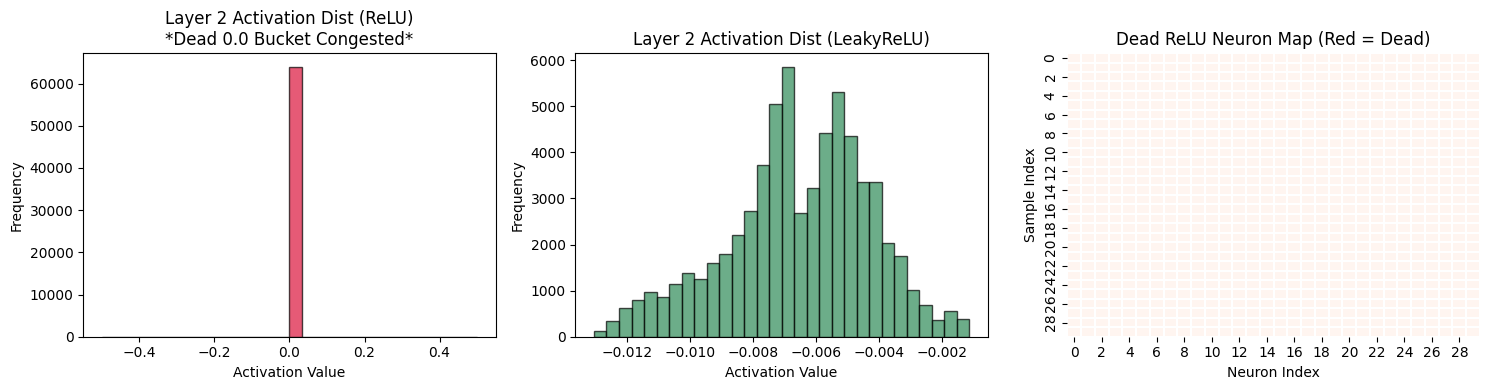

[실험 B]
정량적 비교 데이터
  - ReLU 활성화 최종 검증 정확도        : 50.00% | 최대 관측 Dead ReLU 비율: 100.00%
  - LeakyReLU 활성화 최종 검증 정확도   : 68.00% | Dead ReLU 비율: 0.00%
  - Sigmoid 활성화 최종 검증 정확도     : 83.40% (Gradient Vanishing)


In [ ]:
# 시각화
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(relu_act2.flatten(), bins=30, color='crimson', alpha=0.7, edgecolor='black')
plt.title('Layer 2 Activation Dist (ReLU)\n*Dead 0.0 Bucket Congested*')
plt.xlabel('Activation Value'); plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(leaky_act2.flatten(), bins=30, color='seagreen', alpha=0.7, edgecolor='black')
plt.title('Layer 2 Activation Dist (LeakyReLU)')
plt.xlabel('Activation Value'); plt.ylabel('Frequency')

plt.subplot(1, 3, 3)

sns.heatmap(relu_act2[:30, :30] == 0, cmap='Reds', cbar=False, linewidths=0.05)
plt.title('Dead ReLU Neuron Map (Red = Dead)')
plt.xlabel('Neuron Index'); plt.ylabel('Sample Index')
plt.tight_layout(); plt.show()

print("[실험 B]")
print(f"정량적 비교 데이터")
print(f"  - ReLU 활성화 최종 검증 정확도        : {relu_acc:.2f}% | 최대 관측 Dead ReLU 비율: {max(relu_dead):.2f}%")
print(f"  - LeakyReLU 활성화 최종 검증 정확도   : {leaky_acc:.2f}% | Dead ReLU 비율: 0.00%")
print(f"  - Sigmoid 활성화 최종 검증 정확도     : {sigmoid_acc:.2f}% (Gradient Vanishing)")


[실험 C]


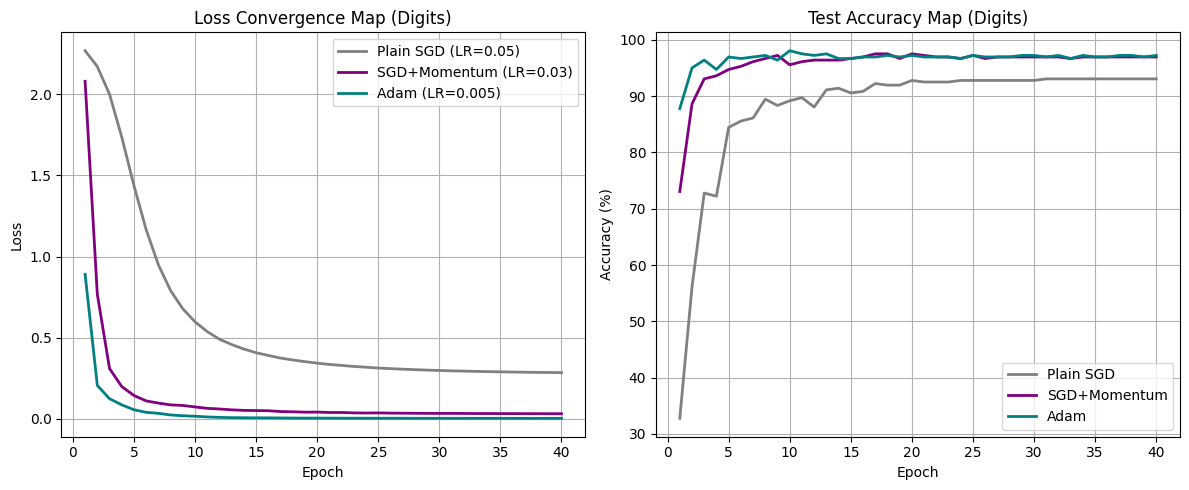

[실험 C]
정량적 비교 데이터
  - Plain SGD 최종 정확도        : 93.06% | 최종 에폭 Loss: 0.2842
  - SGD+Momentum 최종 정확도     : 96.94% | 최종 에폭 Loss: 0.0307
  - Adam 최종 정확도             : 97.22% | 최종 에폭 Loss: 0.0022


In [ ]:

print("[실험 C]")

digits_c = load_digits()
X_c, y_c = digits_c.data / 16.0, digits_c.target
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

train_loader_c = DataLoader(TensorDataset(torch.FloatTensor(X_train_c), torch.LongTensor(y_train_c)), batch_size=32, shuffle=True)
test_loader_c = DataLoader(TensorDataset(torch.FloatTensor(X_test_c), torch.LongTensor(y_test_c)), batch_size=32, shuffle=False)

def run_experiment_c(opt_type, initial_lr):
    model = nn.Sequential(
        nn.Linear(64, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    ).to(device)


    if opt_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=initial_lr)
    elif opt_type == 'Momentum':
        optimizer = optim.SGD(model.parameters(), lr=initial_lr, momentum=0.9)
    elif opt_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=initial_lr)


    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
    loss_fn = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'test_acc': []}

    for epoch in range(40):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader_c:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        scheduler.step()
        history['train_loss'].append(running_loss / len(train_loader_c.dataset))

        # 테스트 검증 평가
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader_c:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        history['test_acc'].append((correct / total) * 100)

    return history


sgd_history = run_experiment_c('SGD', 0.05)
momentum_history = run_experiment_c('Momentum', 0.03)
adam_history = run_experiment_c('Adam', 0.005)

epochs_c = range(1, 41)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_c, sgd_history['train_loss'], label='Plain SGD (LR=0.05)', color='gray', linewidth=2)
plt.plot(epochs_c, momentum_history['train_loss'], label='SGD+Momentum (LR=0.03)', color='purple', linewidth=2)
plt.plot(epochs_c, adam_history['train_loss'], label='Adam (LR=0.005)', color='teal', linewidth=2)
plt.title('Loss Convergence Map (Digits)'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_c, sgd_history['test_acc'], label='Plain SGD', color='gray', linewidth=2)
plt.plot(epochs_c, momentum_history['test_acc'], label='SGD+Momentum', color='purple', linewidth=2)
plt.plot(epochs_c, adam_history['test_acc'], label='Adam', color='teal', linewidth=2)
plt.title('Test Accuracy Map (Digits)'); plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(True)

plt.tight_layout(); plt.show()

print("[실험 C]")
print(f"정량적 비교 데이터")
print(f"  - Plain SGD 최종 정확도        : {sgd_history['test_acc'][-1]:.2f}% | 최종 에폭 Loss: {sgd_history['train_loss'][-1]:.4f}")
print(f"  - SGD+Momentum 최종 정확도     : {momentum_history['test_acc'][-1]:.2f}% | 최종 에폭 Loss: {momentum_history['train_loss'][-1]:.4f}")
print(f"  - Adam 최종 정확도             : {adam_history['test_acc'][-1]:.2f}% | 최종 에폭 Loss: {adam_history['train_loss'][-1]:.4f}")